In [71]:
import netCDF4
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timezone
import math
import cmocean
from geopy import distance
from scipy.stats import cumfreq
from scipy.interpolate import griddata
import shapefile
import numpy.polynomial.polynomial as poly
from functions import *


%matplotlib widget 
# Autosave every second:
%autosave 1

Autosaving every 1 seconds


In [72]:
# Calibration_wrong
A0=-2.40653000000E+0001    
A1=8.10158000000E-0003  
A2=7.89804000000E-0009
A3=0
A4=0
A5=0

# Calibration_old (3 October)
A0_old=-2.41354000000E+0001  
A1_old=8.06568000000E-0003  
A2_old=1.58428000000E-0009 
A3_old=-7.61843000000E-0015
A4_old=0
A5_old=0

In [73]:
# Load data profiles
foldername='../../Profiles_displacement_2019/Level2A/'
filename='L2A_20191028_090242.nc'
profref='L2A_20191003_104429.nc'

nc=netCDF4.Dataset(foldername+filename, mode='r', format='NETCDF4_CLASSIC')
press=nc.variables["Press"][:]
cond=nc.variables["Cond"][:]
nc.close()

nc2=netCDF4.Dataset(foldername+profref, mode='r', format='NETCDF4_CLASSIC')
press_ref=nc2.variables["Press"][:]
cond_ref=nc2.variables["Cond"][:]
nc2.close()

In [74]:
# Calculate raw signal
raw_signal=np.full(len(press),np.nan)
for k in np.arange(1,len(raw_signal)):
    poly_roots=poly.polyroots([A0+A5-press[k],A1,A2,A3,A4])
    poly_roots=poly_roots[np.logical_and(poly_roots>0,poly_roots<60000)]
    if len(poly_roots)>1:
        log('Several solutions possible')
    elif np.any(poly_roots)==0:
        log('No solution found')
    else:
        raw_signal[k]=poly_roots[0]
 

In [75]:
# Apply old calibration
press_corr=np.polyval([A4_old,A3_old,A2_old,A1_old,A0_old+A5_old],raw_signal)

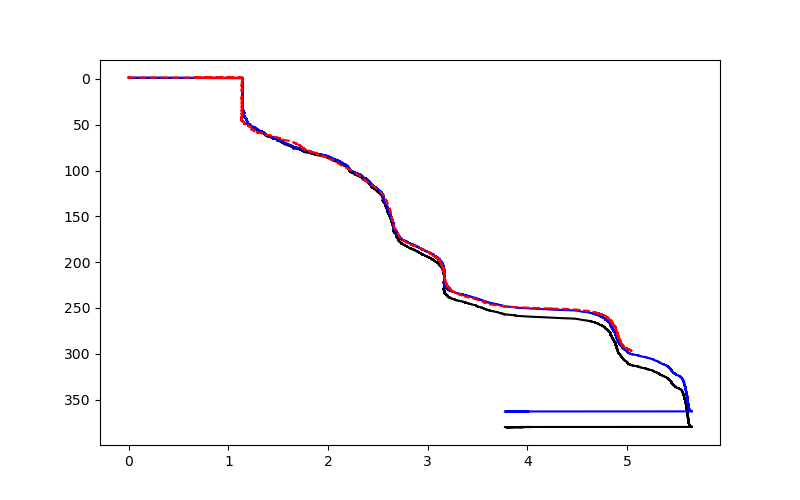

In [76]:
# Figure
indmax=np.argmax(press)
indmax_ref=np.argmax(press_ref)
fig,ax=plt.subplots(figsize=(8,5))
ax.plot(cond[:indmax],press[:indmax],'k')
ax.plot(cond[:indmax],press_corr[:indmax],'b')
ax.plot(cond_ref[:indmax_ref],press_ref[:indmax_ref],'--r')
ax.invert_yaxis()